# brute force

In [ ]:
from itertools import combinations, chain
from tqdm import tqdm

def mckay_with_limits(n, min_part, max_part):
    """
    Integer partitions of n, in reverse lexicographic order, with limits on the minimum and maximum part sizes.
    """
    if n == 0:
        yield []
    if n <= 0:
        return
    partition = [n]
    last_nonunit = (n > 1) - 1
    while True:
        # Check the part size limits
        if all(min_part <= x <= max_part for x in partition):
            yield partition[:]
        
        if last_nonunit < 0:
            return
        if partition[last_nonunit] == 2:
            partition[last_nonunit] = 1
            partition.append(1)
            last_nonunit -= 1
            continue
        replacement = partition[last_nonunit] - 1
        total_replaced = replacement + len(partition) - last_nonunit
        reps, rest = divmod(total_replaced, replacement)
        partition[last_nonunit:] = reps * [replacement]
        if rest:
            partition.append(rest)
        last_nonunit = len(partition) - (partition[-1] == 1) - 1

def find_unique_partitions_with_limits(n, length, max_pairs, min_part, max_part):
    """
    Find up to max_pairs of partitions of n with a specified length that are disjoint in their parts,
    ensuring each part is between min_part and max_part, and no subset sums match except for the total sum.
    """
    def subset_sums(partition):
        """Generate all possible subset sums of a partition."""
        return set(sum(subset) for subset in chain.from_iterable(combinations(partition, r) for r in range(1, len(partition)+1)))

    length_partitions = []
    for p in mckay_with_limits(n, min_part, max_part):
        if len(p) == length:
            length_partitions.append(p[:])
    print('Partitions generated')

    print('Calculating combinations...')
    unique_pairs = []
    for part1, part2 in tqdm(combinations(length_partitions, 2)):
        if len(unique_pairs) >= max_pairs:
            break
        if set(part1).isdisjoint(set(part2)):
            sums1 = subset_sums(part1)
            sums2 = subset_sums(part2)
            common_sums = sums1.intersection(sums2)
            if common_sums == {n}:
                unique_pairs.append((part1, part2))
    
    return unique_pairs

# Example usage
target_number = 50
partition_length = 8
max_pairs = 10  # Limit the number of unique pairs returned
min_part = 2    # Minimum value allowed for any part in the partition
max_part = 20   # Maximum value allowed for any part in the partition

unique_partitions = find_unique_partitions_with_limits(target_number, partition_length, max_pairs, min_part, max_part)

for pair in unique_partitions:
    print(pair)

Partitions generated
Calculating combinations...


7249225it [00:15, 461341.17it/s]


KeyboardInterrupt: 

In [ ]:
from itertools import combinations, chain

def mckay_with_limits(n, min_part, max_part):
    """
    Integer partitions of n, in reverse lexicographic order, with limits on the minimum and maximum part sizes.
    """
    if n == 0:
        yield []
    if n <= 0:
        return
    partition = [n]
    last_nonunit = (n > 1) - 1
    while True:
        # Check the part size limits
        if all(min_part <= x <= max_part for x in partition):
            yield partition[:]
        
        if last_nonunit < 0:
            return
        if partition[last_nonunit] == 2:
            partition[last_nonunit] = 1
            partition.append(1)
            last_nonunit -= 1
            continue
        replacement = partition[last_nonunit] - 1
        total_replaced = replacement + len(partition) - last_nonunit
        reps, rest = divmod(total_replaced, replacement)
        partition[last_nonunit:] = reps * [replacement]
        if rest:
            partition.append(rest)
        last_nonunit = len(partition) - (partition[-1] == 1) - 1

def find_unique_partitions_with_limits(n, length, max_pairs, min_part, max_part, max_overlap):
    """
    Find up to max_pairs of partitions of n with a specified length that are disjoint in their parts,
    ensuring each part is between min_part and max_part, and no subset sums match more than max_overlap times.
    """
    def limited_subset_sums(partition, max_depth):
        """Generate a limited set of subset sums of a partition."""
        subset_sums = set()
        for r in range(1, min(max_depth, len(partition)) + 1):
            for subset in combinations(partition, r):
                subset_sums.add(sum(subset))
        return subset_sums

    print('Generating partitions...')
    length_partitions = []
    for p in mckay_with_limits(n, min_part, max_part):
        if len(p) == length:
            length_partitions.append(p[:])
    print('Partitions generated')

    print('Calculating combinations...')
    unique_pairs = []
    for part1, part2 in tqdm(combinations(length_partitions, 2)):
        if len(unique_pairs) >= max_pairs:
            break
        if set(part1).isdisjoint(set(part2)):
            sums1 = limited_subset_sums(part1, length // 2)
            sums2 = limited_subset_sums(part2, length // 2)
            common_sums = sums1.intersection(sums2)
            if len(common_sums) <= max_overlap:
                print(common_sums)
                unique_pairs.append((part1, part2))
    
    return unique_pairs

# Example usage
target_number = 150
partition_length = 15
max_pairs = 10  # Limit the number of unique pairs returned
min_part = 2   # Minimum value allowed for any part in the partition
max_part = 50   # Maximum value allowed for any part in the partition
max_overlap = 5 # Allow up to 3 overlapping subset sums

unique_partitions = find_unique_partitions_with_limits(target_number, partition_length, max_pairs, min_part, max_part, max_overlap)

for pair in unique_partitions:
    print(pair)

KeyboardInterrupt: 

In [ ]:
def find_unique_partitions_with_fptas(n, length, max_pairs, min_part, max_part, epsilon, max_overlap):
    """
    Find up to max_pairs of partitions of n with a specified length that are disjoint in their parts,
    ensuring each part is between min_part and max_part, and using FPTAS for subset sums.
    """
    def limited_subset_sums(elements, target_sum, epsilon):
        """
        Generate a sparse list of subset sums from the input elements using FPTAS.
        
        Args:
        - elements: List of input numbers.
        - target_sum: The target sum T for the subset sum problem.
        - epsilon: The allowable error margin for approximation.
        
        Returns:
        - A list of subset sums that approximates the maximum subset sum ≤ T.
        """
        n = len(elements)
        L = [0]  # Initialize the list with the sum of the empty subset
        
        for x in elements:
            # Create a new list to store possible sums with the current element
            U = [y + x for y in L] + L
            U.sort()
            
            # Trim the list
            new_L = []
            y = U[0]
            new_L.append(y)
            
            for z in U:
                if y + epsilon * target_sum / n < z <= target_sum:
                    y = z
                    new_L.append(z)
            
            L = new_L
        
        return L

    print('Generating partitions...')
    length_partitions = []
    for p in tqdm(mckay_with_limits(n, min_part, max_part)):
        if len(p) == length:
            length_partitions.append(p[:])
    print('Partitions generated')

    print('Calculating combinations...')
    unique_pairs = []
    for part1, part2 in tqdm(combinations(length_partitions, 2)):
        if len(unique_pairs) >= max_pairs:
            break
        if set(part1).isdisjoint(set(part2)):
            sums1 = limited_subset_sums(part1, n, epsilon)
            sums2 = limited_subset_sums(part2, n, epsilon)
            common_sums = set(sums1).intersection(set(sums2))
            if len(common_sums) <= max_overlap:
                print(common_sums)
                unique_pairs.append((part1, part2))
    
    return unique_pairs

# Example usage
target_number = 100
partition_length = 8
max_pairs = 10  # Limit the number of unique pairs returned
min_part = 2    # Minimum value allowed for any part in the partition
max_part = 30   # Maximum value allowed for any part in the partition
epsilon = 0.1   # Allowable error margin for approximation
max_overlap = 10 # Allow up to k overlapping subset sums

unique_partitions = find_unique_partitions_with_fptas(target_number, partition_length, max_pairs, min_part, max_part, epsilon, max_overlap)

for pair in unique_partitions:
    print(pair)

Generating partitions...


NameError: name 'tqdm' is not defined

In [ ]:
from itertools import combinations, chain
from tqdm import tqdm

def mckay_with_limits(n, min_part, max_part):
    """
    Generate all integer partitions of n in reverse lexicographic order, 
    with limits on the minimum and maximum part sizes.
    
    Args:
    - n: The target number to partition.
    - min_part: Minimum allowable size for each part in the partition.
    - max_part: Maximum allowable size for each part in the partition.
    
    Returns:
    - A list of partitions that meet the criteria.
    """
    partitions = []
    
    if n == 0:
        return [[]]
    if n <= 0:
        return []
    
    partition = [n]
    last_nonunit = (n > 1) - 1
    while True:
        # Check the part size limits
        if all(min_part <= x <= max_part for x in partition):
            partitions.append(partition[:])
        
        if last_nonunit < 0:
            break
        if partition[last_nonunit] == 2:
            partition[last_nonunit] = 1
            partition.append(1)
            last_nonunit -= 1
            continue
        replacement = partition[last_nonunit] - 1
        total_replaced = replacement + len(partition) - last_nonunit
        reps, rest = divmod(total_replaced, replacement)
        partition[last_nonunit:] = reps * [replacement]
        if rest:
            partition.append(rest)
        last_nonunit = len(partition) - (partition[-1] == 1) - 1
        
    return partitions

def find_unique_partitions_with_fptas(partitions, n, length, max_pairs, epsilon, max_overlap):
    """
    Find up to max_pairs of partitions with a specified length that are disjoint in their parts,
    ensuring each part is between min_part and max_part, and using FPTAS for subset sums.
    
    Args:
    - partitions: A list of partitions to consider.
    - n: The target sum for the subset sum problem.
    - length: The required length of partitions to consider.
    - max_pairs: Maximum number of unique pairs to return.
    - epsilon: The allowable error margin for approximation.
    - max_overlap: Maximum allowed number of overlapping subset sums.
    
    Returns:
    - A list of unique partition pairs.
    """
    def limited_subset_sums(elements, target_sum, epsilon):
        """
        Generate a sparse list of subset sums from the input elements using FPTAS.
        
        Args:
        - elements: List of input numbers.
        - target_sum: The target sum T for the subset sum problem.
        - epsilon: The allowable error margin for approximation.
        
        Returns:
        - A list of subset sums that approximates the maximum subset sum ≤ T.
        """
        n = len(elements)
        L = [0]  # Initialize the list with the sum of the empty subset
        
        for x in elements:
            # Create a new list to store possible sums with the current element
            U = [y + x for y in L] + L
            U.sort()
            
            # Trim the list
            new_L = []
            y = U[0]
            new_L.append(y)
            
            for z in U:
                if y + epsilon * target_sum / n < z <= target_sum:
                    y = z
                    new_L.append(z)
            
            L = new_L
        
        return L

    print('Calculating combinations...')
    unique_pairs = []
    for part1, part2 in tqdm(combinations(partitions, 2)):
        if len(part1) == length and len(part2) == length:
            if len(unique_pairs) >= max_pairs:
                break
            if set(part1).isdisjoint(set(part2)):
                sums1 = limited_subset_sums(part1, n, epsilon)
                sums2 = limited_subset_sums(part2, n, epsilon)
                common_sums = set(sums1).intersection(set(sums2))
                if len(common_sums) <= max_overlap:
                    print(common_sums)
                    print([part1, part2])
                    unique_pairs.append((part1, part2))
    
    return unique_pairs

In [ ]:
# Example usage
target_number = 100
partition_length = 8
max_pairs = 10  # Limit the number of unique pairs returned
min_part = 2    # Minimum value allowed for any part in the partition
max_part = 30   # Maximum value allowed for any part in the partition
epsilon = 0.1   # Allowable error margin for approximation
max_overlap = 10 # Allow up to k overlapping subset sums

In [ ]:
# Generate partitions with constraints
partitions = mckay_with_limits(target_number, min_part, max_part)

In [ ]:
len(partitions)

17851324

In [ ]:
from itertools import combinations, chain
from tqdm import tqdm

def mckay_with_limits(n, min_part, max_part, length):
    """
    Generate all integer partitions of n in reverse lexicographic order, 
    with limits on the minimum and maximum part sizes and a specified length.
    
    Args:
    - n: The target number to partition.
    - min_part: Minimum allowable size for each part in the partition.
    - max_part: Maximum allowable size for each part in the partition.
    - length: Desired length of each partition.
    
    Returns:
    - A list of partitions that meet the criteria.
    """
    partitions = []
    
    if n == 0:
        return [[]]
    if n <= 0:
        return []
    
    partition = [n]
    last_nonunit = (n > 1) - 1
    while True:
        # Check the part size and length limits
        if len(partition) == length and all(min_part <= x <= max_part for x in partition):
            partitions.append(partition[:])
        
        if last_nonunit < 0:
            break
        if partition[last_nonunit] == 2:
            partition[last_nonunit] = 1
            partition.append(1)
            last_nonunit -= 1
            continue
        replacement = partition[last_nonunit] - 1
        total_replaced = replacement + len(partition) - last_nonunit
        reps, rest = divmod(total_replaced, replacement)
        partition[last_nonunit:] = reps * [replacement]
        if rest:
            partition.append(rest)
        last_nonunit = len(partition) - (partition[-1] == 1) - 1
        
    return partitions

def limited_subset_sums(elements, target_sum, epsilon):
    """
    Generate a sparse list of subset sums from the input elements using FPTAS.
    
    Args:
    - elements: List of input numbers.
    - target_sum: The target sum T for the subset sum problem.
    - epsilon: The allowable error margin for approximation.
    
    Returns:
    - A list of subset sums that approximates the maximum subset sum ≤ T.
    """
    n = len(elements)
    L = [0]  # Initialize the list with the sum of the empty subset
    
    for x in elements:
        # Create a new list to store possible sums with the current element
        U = [y + x for y in L] + L
        U.sort()
        
        # Trim the list
        new_L = []
        y = U[0]
        new_L.append(y)
        
        for z in U:
            if y + epsilon * target_sum / n < z <= target_sum:
                y = z
                new_L.append(z)
        
        L = new_L
    
    return L

def find_unique_partitions_with_fptas(partitions, n, max_pairs, epsilon, max_overlap):
    """
    Find up to max_pairs of partitions with specified conditions that are disjoint in their parts,
    and using FPTAS for subset sums.
    
    Args:
    - partitions: A list of partitions to consider.
    - n: The target sum for the subset sum problem.
    - max_pairs: Maximum number of unique pairs to return.
    - epsilon: The allowable error margin for approximation.
    - max_overlap: Maximum allowed number of overlapping subset sums.
    
    Returns:
    - A list of unique partition pairs.
    """
    print('Calculating combinations...')
    unique_pairs = []
    # Use combinations to generate all pairs without duplicates
    for part1, part2 in tqdm(combinations(partitions, 2), total=len(partitions) * (len(partitions) - 1) // 2):
        if len(unique_pairs) >= max_pairs:
            break
        # Quick disjoint check
        if not set(part1).intersection(part2):
            sums1 = limited_subset_sums(part1, n, epsilon)
            sums2 = limited_subset_sums(part2, n, epsilon)
            common_sums = set(sums1).intersection(set(sums2))
            if len(common_sums) <= max_overlap:
                print(common_sums)
                unique_pairs.append((part1, part2))
    
    return unique_pairs

In [ ]:
# Example usage
target_number = 120
partition_length = 20
max_pairs = 3  # Limit the number of unique pairs returned
min_part = 3    # Minimum value allowed for any part in the partition
max_part = 15   # Maximum value allowed for any part in the partition
epsilon = 0.1   # Allowable error margin for approximation
max_overlap = 8 # Allow up to k overlapping subset sums

In [ ]:
# Generate partitions with constraints
partitions = mckay_with_limits(target_number, min_part, max_part, partition_length)

In [ ]:
len(partitions)

NameError: name 'partitions' is not defined

In [ ]:
# Find unique pairs with the FPTAS approach
unique_partitions = find_unique_partitions_with_fptas(list(reversed(partitions)), target_number, max_pairs, epsilon, 8)

for pair in unique_partitions:
    print(pair)

Calculating combinations...


  0%|          | 14962/26296927111 [00:01<894:43:21, 8164.20it/s] 

{0, 120, 90, 60, 30}


  0%|          | 177346/26296927111 [00:27<1037:35:14, 7040.04it/s]

{0, 120, 90, 60, 30}


  0%|          | 218117/26296927111 [00:35<1201:27:50, 6079.78it/s]

{0, 120, 90, 60, 30}
([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6], [10, 10, 10, 10, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])
([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6], [15, 10, 10, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])
([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6], [15, 15, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])


In [ ]:
[15, 15, 15, 12, 6, 6, 6, 6, 6, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], [10, 10, 10, 10, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

## check

In [ ]:
def subset_sums(partition):
        """Generate all possible subset sums of a partition."""
        return set(sum(subset) for subset in chain.from_iterable(combinations(partition, r) for r in range(1, len(partition)+1)))

In [ ]:
part1 = [13,
 23,
 13,
 13,
 13,
 13,
 13,
 13,
 23,
 13]
part2 = [10,
 10,
 10,
 20,
 25,
 20,
 10,
 15,
 10,
 20]

In [ ]:
set(part1).isdisjoint(set(part2))

True

In [ ]:
sums1 = subset_sums(part1)
sums2 = subset_sums(part2)
common_sums = set(sums1).intersection(set(sums2))

In [ ]:
common_sums

{65, 75, 85, 150}

# recursive partitioning

## method 1

In [3]:
import sys
sys.path.insert(1, '/Users/linusrandud/Documents/UoM/ERP/MscDissertation/Deep-Opt')

In [4]:
import numpy as np
import random
import torch
from COProblems.MKP import MKP
from COProblems.QUBO import QUBO
from Models.DOAE import DOAE
from OptimAE import OptimAEHandler
import json
import matplotlib.pyplot as plt

def generate_qubo_matrix(S):
    n = len(S)
    c = sum(S)
    Q = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i == j:
                Q[i, j] = S[i] * (S[i] - c)
            else:
                Q[i, j] = S[i] * S[j]

    return Q

def algorithm(array):
    """
    Deep Optimization (DO) based algorithm for partitioning.
    
    Args:
        array (list): Input array of integers.

    Returns:
        np.ndarray: Solutions as binary arrays.
    """
    arr_len = len(array)
    final_durations = list(range(1, arr_len + 1))
    Q = generate_qubo_matrix(final_durations)

    # Generate the text file content
    lines = []
    lines.append("1\n")  # Number of problem instances

    # Collect non-zero entries
    n = Q.shape[0]
    non_zero_entries = []
    for i in range(n):
        for j in range(i, n):
            if Q[i][j] != 0:
                non_zero_entries.append((i + 1, j + 1, int(Q[i][j])))

    # Add the number of variables and number of non-zero entries
    lines.append(f"{n} {len(non_zero_entries)}\n")

    # Add the non-zero entries to lines
    for entry in non_zero_entries:
        i, j, value = entry
        lines.append(f"{i} {j} {value}\n")

    # Write to file
    filename = f'trialrdo_{arr_len}'
    with open(f"../data/qubo/{filename}.txt", "w") as f:
        f.writelines(lines)

    # Initialize device
    device = torch.device("cpu")

    # Define the file path and problem type
    file_paths = [f'../data/qubo/{filename}.txt']
    params = {
        'change_tolerance': 20,
        'problem_size': arr_len,
        'pop_size': 1000,
        'dropout_prob': 0.2,
        'l1_coef': 0.0001,
        'l2_coef': 0.0001,
        'learning_rate': 0.002,
        'max_depth': 6,
        'compression_ratio': 0.8,
        'problem_instance_id': 0,
        'deepest_only': True,
        'encode': True,
        'repair_solutions': True,
        'patience': 5,
        'delta_mean_population': 0.1,
        'check_constraints': 'None',
        'penalty_mult': 5
    }

    # Initialize problem
    problem = QUBO(file_paths[0], params['problem_instance_id'], device)

    # Initialize model and handler
    model = DOAE(arr_len, params['dropout_prob'], device)
    handler = OptimAEHandler(model, problem, device)

    # Generate initial population
    population, fitnesses = handler.generate_population(params['pop_size'], params['check_constraints'], params['penalty_mult'])
    population, fitnesses, _, _ = handler.hilldescent(population, fitnesses, params['change_tolerance'], params['check_constraints'], params['penalty_mult'])

    # Get solutions
    def find_extreme_indices(fitnesses, mode='low'):
        if mode not in ['high', 'low']:
            raise ValueError("Mode should be either 'high' or 'low'")

        if mode == 'high':
            extreme_value = max(fitnesses)
        else:
            extreme_value = min(fitnesses)

        return [i for i, value in enumerate(fitnesses) if value == extreme_value]

    def convert_tensor_to_unique_np_arrays(tensor):
        np_array = tensor.numpy()
        np_array[np_array == -1] = 0

        unique_arrays = set()
        unique_np_arrays = []

        for arr in np_array:
            arr_tuple = tuple(arr)
            if arr_tuple not in unique_arrays:
                unique_arrays.add(arr_tuple)
                unique_np_arrays.append(arr)

        return np.array(unique_np_arrays)

    def get_solutions(population, fitnesses, mode='low'):
        return convert_tensor_to_unique_np_arrays(population[find_extreme_indices(fitnesses, mode)])

    solutions = get_solutions(population, fitnesses, mode='low')
    return solutions

def check_equal_count(binary_output, array):
    count_0 = np.sum(binary_output == 0)
    count_1 = np.sum(binary_output == 1)
    sum_0 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 0)
    sum_1 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 1)
    return (count_0 == count_1) and (sum_0 == sum_1)

def check_alternate(binary_output, array):
    count_0 = np.sum(binary_output == 0)
    count_1 = np.sum(binary_output == 1)
    sum_0 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 0)
    sum_1 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 1)
    return (count_0 % 2 == 0 or count_1 % 2 == 0)

def partition_elements(array, binary_output):
    partition_1 = [array[i] for i in range(len(array)) if binary_output[i] == 1]
    partition_2 = [array[i] for i in range(len(array)) if binary_output[i] == 0]
    return partition_1, partition_2

def iterative_partitioning(array, iterations=5):
    partition_1, partition_2 = [], []  # Initialize partitions to avoid unbound error
    for _ in range(iterations):
        solutions = algorithm(array)  # Generate solutions

        # Try to find a valid solution with equal counts and sums
        valid_solutions = [sol for sol in solutions if check_equal_count(sol, array)]

        if not valid_solutions:
            # Fallback: find solutions where sums match and counts are divisible by 2
            valid_solutions = [sol for sol in solutions if check_alternate(sol, array)]

        if not valid_solutions:
            print("No valid solutions found.")
            break

        # Pick the first valid solution
        best_solution = valid_solutions[0]

        # Partition the elements
        partition_1, partition_2 = partition_elements(array, best_solution)

        # Choose the partition with length divisible by 2
        if len(partition_1) % 2 == 0:
            array = partition_1
        elif len(partition_2) % 2 == 0:
            array = partition_2
        else:
            print("No partition with length divisible by 2 found.")
            break

    return partition_1, partition_2

# Example usage
array = list(range(1, 1001))  # Create an array with elements 1 to 1000
final_partition_1, final_partition_2 = iterative_partitioning(array, iterations=5)
print("Final Partition 1:", final_partition_1)
print("Final Partition 2:", final_partition_2)

Instance has been loaded


/var/folders/fh/7sz134vx5jq6_78w16smcs3h0000gn/T/ipykernel_20181/4041355805.py:136: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sum_0 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 0)
/var/folders/fh/7sz134vx5jq6_78w16smcs3h0000gn/T/ipykernel_20181/4041355805.py:137: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sum_1 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 1)
/var/folders/fh/7sz134vx5jq6_78w16smcs3h0000gn/T/ipykernel_20181/4041355805.py:143: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sum_0 = np.sum(array[i] for i in ra

Instance has been loaded
No valid solutions found.
Final Partition 1: [1, 2, 3, 6, 13, 15, 16, 19, 20, 25, 26, 28, 29, 30, 34, 35, 36, 39, 40, 41, 42, 44, 45, 49, 55, 60, 62, 63, 65, 66, 69, 70, 74, 76, 77, 79, 82, 83, 85, 90, 91, 93, 95, 98, 101, 102, 105, 107, 110, 113, 114, 115, 116, 118, 119, 120, 127, 132, 133, 135, 136, 137, 140, 146, 147, 148, 149, 151, 153, 155, 156, 158, 159, 162, 163, 164, 167, 168, 169, 172, 173, 181, 182, 185, 186, 188, 191, 194, 198, 199, 201, 204, 206, 208, 210, 213, 216, 217, 219, 220, 223, 225, 226, 227, 229, 230, 233, 236, 237, 239, 240, 242, 243, 245, 246, 247, 248, 249, 250, 251, 254, 255, 257, 258, 259, 262, 263, 265, 266, 268, 270, 271, 272, 273, 276, 278, 283, 288, 291, 292, 298, 300, 303, 304, 306, 307, 309, 310, 311, 317, 318, 320, 325, 326, 327, 328, 329, 330, 331, 332, 334, 335, 336, 338, 339, 340, 341, 344, 345, 346, 347, 348, 352, 353, 361, 362, 363, 364, 366, 367, 369, 370, 373, 375, 379, 381, 382, 383, 384, 389, 390, 391, 393, 394, 395, 39

In [5]:
len(final_partition_1), len(final_partition_2), sum(final_partition_1), sum(final_partition_2)

(30, 30, 15793, 15682)

In [6]:
def iterative_partitioning_until_condition(array):
    partition_1, partition_2 = [], []  # Initialize partitions to avoid unbound error
    iteration = 0
    while True:
        iteration += 1
        solutions = algorithm(array)  # Generate solutions

        # Try to find a valid solution with equal counts and sums
        valid_solutions = [sol for sol in solutions if check_equal_count(sol, array)]

        if not valid_solutions:
            # Fallback: find solutions where sums match and counts are divisible by 2
            valid_solutions = [sol for sol in solutions if check_alternate(sol, array)]

        if not valid_solutions:
            print("No valid solutions found.")
            break

        # Pick the first valid solution
        best_solution = valid_solutions[0]

        # Partition the elements
        partition_1, partition_2 = partition_elements(array, best_solution)

        # Check if partitions have equal length and sum
        if len(partition_1) == len(partition_2) and sum(partition_1) == sum(partition_2):
            print(f"Condition met after {iteration} iterations.")
            break

        # Choose the partition with length divisible by 2
        if len(partition_1) % 2 == 0:
            array = partition_1
        elif len(partition_2) % 2 == 0:
            array = partition_2
        else:
            print("No partition with length divisible by 2 found.")
            break

    return partition_1, partition_2

# Run the updated function
array = list(range(1, 10001))  # Create an array with elements 1 to 1000

# array = []
# for x in range(2000):
#     array.append(random.randint(1, 1000))
    
final_partition_1, final_partition_2 = iterative_partitioning_until_condition(array)
print("Final Partition 1:", final_partition_1)
print("Final Partition 2:", final_partition_2)

Instance has been loaded


/var/folders/fh/7sz134vx5jq6_78w16smcs3h0000gn/T/ipykernel_69996/4041355805.py:136: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sum_0 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 0)
/var/folders/fh/7sz134vx5jq6_78w16smcs3h0000gn/T/ipykernel_69996/4041355805.py:137: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sum_1 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 1)
/var/folders/fh/7sz134vx5jq6_78w16smcs3h0000gn/T/ipykernel_69996/4041355805.py:143: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sum_0 = np.sum(array[i] for i in ra

Instance has been loaded
Instance has been loaded
Instance has been loaded
Instance has been loaded
Instance has been loaded
No valid solutions found.
Final Partition 1: [42, 44, 47, 57, 59, 108, 173, 175, 208, 348, 364, 365, 370, 389, 432, 442, 456, 483, 489, 525, 553, 607, 660, 770, 771, 789, 810, 864, 1109, 1111, 1118, 1148, 1149, 1181, 1188, 1244, 1287, 1337, 1350, 1362, 1376, 1390, 1446, 1452, 1491, 1495, 1502, 1666, 1716, 1735, 1748, 1762, 1766, 1851, 1853, 1879, 1890, 1962, 1979, 1996, 2015, 2019, 2064, 2070, 2093, 2132, 2142, 2152, 2217, 2221, 2237, 2242, 2304, 2420, 2486, 2497, 2515, 2528, 2553, 2574, 2582, 2605, 2619, 2627, 2632, 2715, 2727, 2761, 2774, 2799, 2847, 2906, 2929, 3009, 3169, 3182, 3223, 3266, 3308, 3313, 3318, 3455, 3464, 3490, 3514, 3530, 3547, 3608, 3652, 3710, 3740, 3860, 3911, 3961, 3989, 4005, 4120, 4121, 4128, 4226, 4228, 4282, 4365, 4428, 4530, 4557, 4560, 4564, 4573, 4574, 4606, 4611, 4712, 4781, 4792, 4835, 4848, 4862, 4877, 4883, 4917, 5055, 5090, 5108

In [41]:
len(final_partition_1), len(final_partition_2)

(2, 2)

In [42]:
sum(final_partition_1), sum(final_partition_2)

(13043, 12392)

## method 2

In [3]:
import numpy as np

In [5]:
def generate_qubo_matrix(S):
    n = len(S)
    c = sum(S)
    Q = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                Q[i, j] = S[i] * (S[i] - c)
            else:
                Q[i, j] = S[i] * S[j]
    
    return Q

In [ ]:
def check_equal_count(binary_output):
    """
    Check if the count of 0 and 1 in the binary output is equal or divisible by 2.

    Args:
        binary_output (list or np.ndarray): A binary array (0s and 1s).

    Returns:
        bool: True if counts are equal or divisible by 2, False otherwise.
    """
    count_0 = np.sum(binary_output == 0)
    count_1 = np.sum(binary_output == 1)
    return count_0 == count_1 or (count_0 % 2 == 0 and count_1 % 2 == 0)

def partition_elements(array, binary_output):
    """
    Partition the array based on the binary output.

    Args:
        array (list): Original array of integers.
        binary_output (list or np.ndarray): Binary partition output.

    Returns:
        tuple: Two partitions (Partition 1 with 1s, Partition 2 with 0s).
    """
    partition_1 = [array[i] for i in range(len(array)) if binary_output[i] == 1]
    partition_2 = [array[i] for i in range(len(array)) if binary_output[i] == 0]
    return partition_1, partition_2


In [ ]:
import numpy as np
import torch
from COProblems.MKP import MKP
from COProblems.QUBO import QUBO
from Models.DOAE import DOAE
from OptimAE import OptimAEHandler
import json
import matplotlib.pyplot as plt

def generate_qubo_matrix(S):
    n = len(S)
    c = sum(S)
    Q = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i == j:
                Q[i, j] = S[i] * (S[i] - c)
            else:
                Q[i, j] = S[i] * S[j]

    return Q

def algorithm(array):
    """
    Deep Optimization (DO) based algorithm for partitioning.
    
    Args:
        array (list): Input array of integers.

    Returns:
        np.ndarray: Solutions as binary arrays.
    """
    arr_len = len(array)
    final_durations = list(range(1, arr_len + 1))
    Q = generate_qubo_matrix(final_durations)

    # Generate the text file content
    lines = []
    lines.append("1\n")  # Number of problem instances

    # Collect non-zero entries
    n = Q.shape[0]
    non_zero_entries = []
    for i in range(n):
        for j in range(i, n):
            if Q[i][j] != 0:
                non_zero_entries.append((i + 1, j + 1, int(Q[i][j])))

    # Add the number of variables and number of non-zero entries
    lines.append(f"{n} {len(non_zero_entries)}\n")

    # Add the non-zero entries to lines
    for entry in non_zero_entries:
        i, j, value = entry
        lines.append(f"{i} {j} {value}\n")

    # Write to file
    filename = f'trialrdo_{arr_len}'
    with open(f"../data_gecco/qubo/{filename}.txt", "w") as f:
        f.writelines(lines)

    # Initialize device
    device = torch.device("cpu")

    # Define the file path and problem type
    file_paths = [f'../data_gecco/qubo/{filename}.txt']
    params = {
        'change_tolerance': 20,
        'problem_size': arr_len,
        'pop_size': 1000,
        'dropout_prob': 0.2,
        'l1_coef': 0.0001,
        'l2_coef': 0.0001,
        'learning_rate': 0.002,
        'max_depth': 6,
        'compression_ratio': 0.8,
        'problem_instance_id': 0,
        'deepest_only': True,
        'encode': True,
        'repair_solutions': True,
        'patience': 5,
        'delta_mean_population': 0.1,
        'check_constraints': 'None',
        'penalty_mult': 5
    }

    # Initialize problem
    problem = QUBO(file_paths[0], params['problem_instance_id'], device)

    # Initialize model and handler
    model = DOAE(arr_len, params['dropout_prob'], device)
    handler = OptimAEHandler(model, problem, device)

    # Generate initial population
    population, fitnesses = handler.generate_population(params['pop_size'], params['check_constraints'], params['penalty_mult'])
    population, fitnesses, _, _ = handler.hilldescent(population, fitnesses, params['change_tolerance'], params['check_constraints'], params['penalty_mult'])

    # Get solutions
    def find_extreme_indices(fitnesses, mode='low'):
        if mode not in ['high', 'low']:
            raise ValueError("Mode should be either 'high' or 'low'")

        if mode == 'high':
            extreme_value = max(fitnesses)
        else:
            extreme_value = min(fitnesses)

        return [i for i, value in enumerate(fitnesses) if value == extreme_value]

    def convert_tensor_to_unique_np_arrays(tensor):
        np_array = tensor.numpy()
        np_array[np_array == -1] = 0

        unique_arrays = set()
        unique_np_arrays = []

        for arr in np_array:
            arr_tuple = tuple(arr)
            if arr_tuple not in unique_arrays:
                unique_arrays.add(arr_tuple)
                unique_np_arrays.append(arr)

        return np.array(unique_np_arrays)

    def get_solutions(population, fitnesses, mode='low'):
        return convert_tensor_to_unique_np_arrays(population[find_extreme_indices(fitnesses, mode)])

    solutions = get_solutions(population, fitnesses, mode='low')
    return solutions

def check_equal_count(binary_output, array):
    count_0 = np.sum(binary_output == 0)
    count_1 = np.sum(binary_output == 1)
    sum_0 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 0)
    sum_1 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 1)
    return (count_0 == count_1) and (sum_0 == sum_1)

def check_alternate(binary_output, array):
    count_0 = np.sum(binary_output == 0)
    count_1 = np.sum(binary_output == 1)
    sum_0 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 0)
    sum_1 = np.sum(array[i] for i in range(len(binary_output)) if binary_output[i] == 1)
    return (sum_0 == sum_1) and (count_0 % 2 == 0 or count_1 % 2 == 0)

def partition_elements(array, binary_output):
    partition_1 = [array[i] for i in range(len(array)) if binary_output[i] == 1]
    partition_2 = [array[i] for i in range(len(array)) if binary_output[i] == 0]
    return partition_1, partition_2

def iterative_partitioning(array, iterations=5):
    partition_1, partition_2 = [], []  # Initialize partitions to avoid unbound error
    for _ in range(iterations):
        solutions = algorithm(array)  # Generate solutions

        # Try to find a valid solution with equal counts and sums
        valid_solutions = [sol for sol in solutions if check_equal_count(sol, array)]

        if not valid_solutions:
            # Fallback: find solutions where sums match and counts are divisible by 2
            valid_solutions = [sol for sol in solutions if check_alternate(sol, array)]

        if not valid_solutions:
            print("No valid solutions found.")
            break

        # Pick the first valid solution
        best_solution = valid_solutions[0]

        # Partition the elements
        partition_1, partition_2 = partition_elements(array, best_solution)

        # Prefer partition with length close to previous length / 2 and divisible by 2
        target_length = len(array) // 2
        if len(partition_1) % 2 == 0 and abs(len(partition_1) - target_length) <= abs(len(partition_2) - target_length):
            array = partition_1
        elif len(partition_2) % 2 == 0:
            array = partition_2
        else:
            print("No partition with length divisible by 2 found.")
            break

    return partition_1, partition_2

# Example usage
array = list(range(1, 1001))  # Create an array with elements 1 to 1000
final_partition_1, final_partition_2 = iterative_partitioning(array, iterations=5)
print("Final Partition 1:", final_partition_1)
print("Final Partition 2:", final_partition_2)

## check

In [ ]:
import torch

from COProblems.MKP import MKP
from COProblems.QUBO import QUBO
from Models.DOAE import DOAE
from OptimAE import OptimAEHandler
import json

In [ ]:
# Initialize device
device = torch.device("cpu")
print(device)

# Define the file path and problem type
filename = f'trialrdo_{arr_len}'
problem_type = 'QUBO'
use_wandb = False  # Set to True if using Weights & Biases
check_constraints = 'None' # {'binary', 'lagrangian', None}

json_file = f'../data_gecco/ssjsp/{filename}.json'
file_paths = [f'../data_gecco/qubo/{filename}.txt']
problem_size = int(filename.split('_')[1])
problem_size

cpu


506

In [ ]:
# Parameters
params = {
    'change_tolerance': 20,
    'problem_size': problem_size,
    'pop_size': 1000,
    'dropout_prob': 0.2,
    'l1_coef': 0.0001,
    'l2_coef': 0.0001,
    'learning_rate': 0.002,
    'max_depth': 6,
    'compression_ratio': 0.8,
    'problem_instance_id': 0,
    'deepest_only': True,
    'encode': True,
    'repair_solutions': True,
    'patience': 5,  # Number of iterations to wait
    'delta_mean_population': 0.1,  # Threshold for mean population change
    'check_constraints': check_constraints,
    'penalty_mult': 5
}

# Initialize problem
problem = QUBO(file_paths[0], params['problem_instance_id'], device)

# Unpack parameters
change_tolerance = params['change_tolerance']
problem_size = params['problem_size']
pop_size = params['pop_size']
dropout_prob = params['dropout_prob']
l1_coef = params['l1_coef']
l2_coef = params['l2_coef']
lr = params['learning_rate']
max_depth = params['max_depth']
compression_ratio = params['compression_ratio']
hidden_size = problem_size

# Initialize model and handler
model = DOAE(problem_size, dropout_prob, device)
handler = OptimAEHandler(model, problem, device)

# Generate initial population
population, fitnesses = handler.generate_population(pop_size, params['check_constraints'], params['penalty_mult'])
population, fitnesses, _, _ = handler.hilldescent(population, fitnesses, change_tolerance, params['check_constraints'], params['penalty_mult'])
handler.print_statistics_min(fitnesses)

total_eval = 0
depth = 0

# Store metrics for custom plotting
mean_fitnesses = []
min_max_fitnesses = []
total_evaluations = []
mean_fitness_changes = []

while True:
    if depth < max_depth:
        print("Adding layer")
        hidden_size = round(hidden_size * compression_ratio)
        model.transition(hidden_size)
        depth += 1
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_coef)
    
    print("Learning from population")
    handler.learn_from_population(population, optimizer, l1_coef=l1_coef, batch_size=pop_size)
    
    print("Optimising population")
    population, fitnesses, evaluations, done = handler.optimise_solutions_min(
        population, fitnesses, change_tolerance, encode=params['encode'], repair_solutions=params['repair_solutions'], deepest_only=params['deepest_only'], 
        check_constraints=params['check_constraints'], penalty_mult=params['penalty_mult']
    )
    handler.print_statistics_min(fitnesses)

    mean_fitness = fitnesses.mean().item()
    min_max_fitness = fitnesses.min().item()
    total_eval += evaluations

    mean_fitnesses.append(mean_fitness)
    min_max_fitnesses.append(min_max_fitness)
    total_evaluations.append(total_eval)

    print(f"Evaluations: {total_eval}")
    
    if len(mean_fitnesses) > 1:
        mean_fitness_change = abs(mean_fitnesses[-1] - mean_fitnesses[-2])
        mean_fitness_changes.append(mean_fitness_change)
        
        if len(mean_fitness_changes) >= params['patience']:
            recent_changes = mean_fitness_changes[-params['patience']:]
            if all(change < params['delta_mean_population'] for change in recent_changes):
                print(f"Stopping early due to no significant change in mean fitness over the last {params['patience']} iterations.")
                break
    
    if done:
        print(f"Optimum solution found.")
        break

Instance has been loaded
Min pop fitness: -15654265856.0, Mean pop fitness : -15654259712.0
Adding layer
Learning from population
Optimising population
Min pop fitness: -15654265856.0, Mean pop fitness : -15654259712.0
Evaluations: 22037
Adding layer
Learning from population
Optimising population
Min pop fitness: -15654265856.0, Mean pop fitness : -15654259712.0
Evaluations: 45020
Adding layer
Learning from population
Optimising population
Min pop fitness: -15654265856.0, Mean pop fitness : -15654259712.0
Evaluations: 66020
Adding layer
Learning from population
Optimising population
Min pop fitness: -15654265856.0, Mean pop fitness : -15654259712.0
Evaluations: 87020
Adding layer
Learning from population
Optimising population
Min pop fitness: -15654265856.0, Mean pop fitness : -15654259712.0
Evaluations: 108020
Adding layer
Learning from population
Optimising population
Min pop fitness: -15654265856.0, Mean pop fitness : -15654259712.0
Evaluations: 129020
Stopping early due to no signi

In [ ]:
import wandb
import matplotlib.pyplot as plt

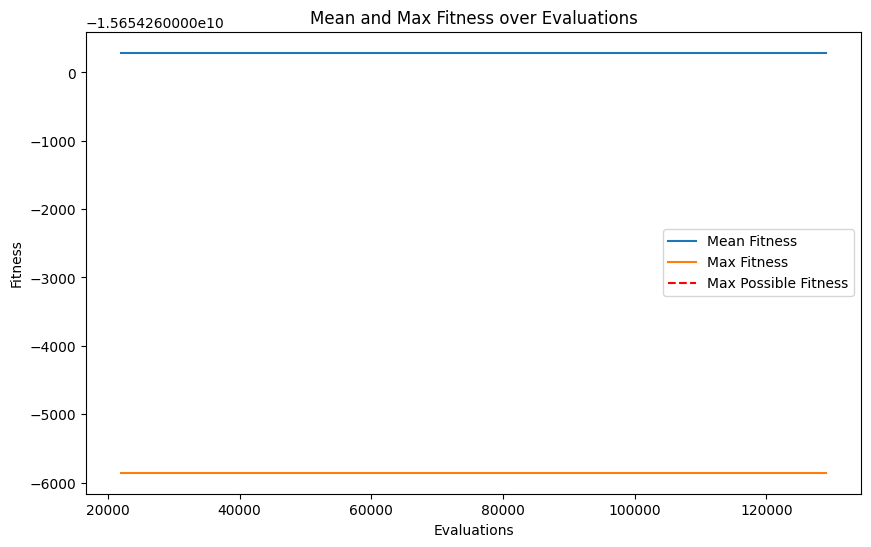

In [ ]:
# Custom plot
plt.figure(figsize=(10, 6))
plt.plot(total_evaluations, mean_fitnesses, label='Mean Fitness')
plt.plot(total_evaluations, min_max_fitnesses, label='Max Fitness')
plt.axhline(y=problem.max_fitness, color='r', linestyle='--', label='Max Possible Fitness')
plt.xlabel('Evaluations')
plt.ylabel('Fitness')
plt.title('Mean and Max Fitness over Evaluations')
plt.legend()

# Save plot to W&B
# wandb.log({"fitness_plot": wandb.Image(plt)})

In [ ]:
population

tensor([[-1., -1.,  1.,  ...,  1.,  1., -1.],
        [ 1., -1., -1.,  ...,  1., -1., -1.],
        [-1.,  1.,  1.,  ..., -1., -1., -1.],
        ...,
        [-1., -1.,  1.,  ..., -1.,  1., -1.],
        [ 1.,  1., -1.,  ..., -1.,  1.,  1.],
        [ 1., -1., -1.,  ..., -1.,  1.,  1.]])

In [ ]:
fitnesses, len(fitnesses)

(tensor([-1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10, -1.5654e+10,
         -1.5654e+10, -1.5654e+10, -1.

In [ ]:
def find_extreme_indices(fitnesses, mode='high'):
    """
    Returns the indices of the highest or lowest values in the list based on the mode.

    Args:
        fitnesses (list or torch.Tensor): A list or tensor of fitness values.
        mode (str): A string that can be either 'high' or 'low'. Defaults to 'high'.

    Returns:
        list: A list of indices corresponding to the extreme values.
    """
    if mode not in ['high', 'low']:
        raise ValueError("Mode should be either 'high' or 'low'")

    if mode == 'high':
        extreme_value = max(fitnesses)
    else:
        extreme_value = min(fitnesses)

    return [i for i, value in enumerate(fitnesses) if value == extreme_value]

In [ ]:
def convert_tensor_to_unique_np_arrays(tensor):
    # Convert the tensor to a numpy array
    np_array = tensor.numpy()
    
    # Replace -1 with 0
    np_array[np_array == -1] = 0
    
    # Use a set to track unique arrays based on element ordering
    unique_arrays = set()
    
    # Create a list to store unique numpy arrays
    unique_np_arrays = []
    
    for arr in np_array:
        # Convert the array to a tuple (hashable type) for uniqueness check
        arr_tuple = tuple(arr)
        
        if arr_tuple not in unique_arrays:
            unique_arrays.add(arr_tuple)
            unique_np_arrays.append(arr)
    
    # Convert the list of unique arrays back to a numpy array
    unique_np_array = np.array(unique_np_arrays)
    
    return unique_np_array

In [ ]:
def get_solutions(population, fitnesses, mode='low'):
    return convert_tensor_to_unique_np_arrays(population[find_extreme_indices(fitnesses, mode)])

In [ ]:
solutions = get_solutions(population, fitnesses, mode='low')
len(solutions)

13

# random 8 bit

In [179]:
duration_len = 100
base_bit = 8 #the higher the more difficult
filename = f'ssjsp_{duration_len}'

In [180]:
def generate_qubo_matrix(S):
    n = len(S)
    c = sum(S)
    Q = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i == j:
                Q[i, j] = S[i] * (S[i] - c)
            else:
                Q[i, j] = S[i] * S[j]

    return Q

In [181]:
def calculate_theo_hard(n, b):
    unique_ss = n*(2**b-1)
    complete_part = 2**n
    hardness = unique_ss/complete_part*100

    print(f'Number of unique subset sum: {unique_ss}')
    print(f'Number of complete partition: {complete_part}')
    print(f'Hardness %: {hardness}')

    return None

In [182]:
import numpy as np

In [183]:
final_durations = values = np.random.randint(1,2**base_bit-1, duration_len)
Q = generate_qubo_matrix(final_durations)

In [184]:
final_durations

array([132,  13,  72,  27,  43,  25, 192,   6, 167, 188,   1, 113, 197,
       209, 192,  53, 247, 190, 246,   7, 199,  83, 197, 240,  13,   3,
        12, 222, 226, 151, 126, 227,  35,  52,  72, 161, 238,  68,  67,
       204,  86,  58, 152,  85,  47, 173, 154,  40, 103, 160, 120, 122,
        71, 152,  47, 113, 123,  34, 220, 142, 171,  30, 234,  30,  17,
       154, 154, 189,  92, 131,  93, 139, 231,  89, 142,  41,  91, 243,
        77, 124,  15,  14, 144,  70,  50, 212, 163,  99, 161,  32, 147,
       179,   7, 171, 216, 200, 182,   7, 119,  44])

In [185]:
calculate_theo_hard(duration_len, base_bit) #%: 1.8669045833583425e-55

Number of unique subset sum: 25500
Number of complete partition: 1267650600228229401496703205376
Hardness %: 2.01159530831358e-24


In [186]:
# Generate the text file content
lines = []
lines.append("1\n")  # Number of problem instances

# Collect non-zero entries
n = Q.shape[0]
non_zero_entries = []
for i in range(n):
    for j in range(i, n):
        if Q[i][j] != 0:
            non_zero_entries.append((i + 1, j + 1, int(Q[i][j])))

# Add the number of variables and number of non-zero entries
lines.append(f"{n} {len(non_zero_entries)}\n")

# Add the non-zero entries to lines
for entry in non_zero_entries:
    i, j, value = entry
    lines.append(f"{i} {j} {value}\n")

# Write to file
with open(f"../data_journal/qubo/{filename}.txt", "w") as f:
    f.writelines(lines)

## check

In [187]:
import sys
sys.path.insert(1, '/Users/linusrandud/Documents/UoM/ERP/MscDissertation/Deep-Opt')

In [188]:
import torch

from COProblems.MKP import MKP
from COProblems.QUBO import QUBO
from Models.DOAE import DOAE
from OptimAE import OptimAEHandler
import json

In [189]:
# Initialize device
device = torch.device("cpu")
print(device)

# Define the file path and problem type
problem_type = 'QUBO'
use_wandb = False  # Set to True if using Weights & Biases
check_constraints = 'None' # {'binary', 'lagrangian', None}

json_file = f'../data_journal/ssjsp/{filename}.json'
file_paths = [f'../data_journal/qubo/{filename}.txt']
problem_size = int(filename.split('_')[1])
problem_size

cpu


100

In [190]:
json_file

'../data_journal/ssjsp/ssjsp_100.json'

In [191]:
# Parameters
params = {
    'change_tolerance': 20,
    'problem_size': problem_size,
    'pop_size': problem_size*10,
    'dropout_prob': 0.2,
    'l1_coef': 0.0001,
    'l2_coef': 0.0001,
    'learning_rate': 0.002,
    'max_depth': 6,
    'compression_ratio': 0.8,
    'problem_instance_id': 0,
    'deepest_only': True,
    'encode': True,
    'repair_solutions': True,
    'patience': 5,  # Number of iterations to wait
    'delta_mean_population': 0.1,  # Threshold for mean population change
    'check_constraints': check_constraints,
    'penalty_mult': 5
}

# Initialize problem
problem = QUBO(file_paths[0], params['problem_instance_id'], device)

# Unpack parameters
change_tolerance = params['change_tolerance']
problem_size = params['problem_size']
pop_size = params['pop_size']
dropout_prob = params['dropout_prob']
l1_coef = params['l1_coef']
l2_coef = params['l2_coef']
lr = params['learning_rate']
max_depth = params['max_depth']
compression_ratio = params['compression_ratio']
hidden_size = problem_size

# Initialize model and handler
model = DOAE(problem_size, dropout_prob, device)
handler = OptimAEHandler(model, problem, device)

# Generate initial population
population, fitnesses = handler.generate_population(pop_size, params['check_constraints'], params['penalty_mult'])
population, fitnesses, _, _ = handler.hilldescent(population, fitnesses, change_tolerance, params['check_constraints'], params['penalty_mult'])
handler.print_statistics_min(fitnesses)

total_eval = 0
depth = 0

# Store metrics for custom plotting
mean_fitnesses = []
min_max_fitnesses = []
total_evaluations = []
mean_fitness_changes = []

while True:
    if depth < max_depth:
        print("Adding layer")
        hidden_size = round(hidden_size * compression_ratio)
        model.transition(hidden_size)
        depth += 1
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_coef)
    
    print("Learning from population")
    handler.learn_from_population(population, optimizer, l1_coef=l1_coef, batch_size=pop_size)
    
    print("Optimising population")
    population, fitnesses, evaluations, done = handler.optimise_solutions_min(
        population, fitnesses, change_tolerance, encode=params['encode'], repair_solutions=params['repair_solutions'], deepest_only=params['deepest_only'], 
        check_constraints=params['check_constraints'], penalty_mult=params['penalty_mult']
    )
    handler.print_statistics_min(fitnesses)

    mean_fitness = fitnesses.mean().item()
    min_max_fitness = fitnesses.min().item()
    total_eval += evaluations

    mean_fitnesses.append(mean_fitness)
    min_max_fitnesses.append(min_max_fitness)
    total_evaluations.append(total_eval)

    print(f"Evaluations: {total_eval}")
    
    if len(mean_fitnesses) > 1:
        mean_fitness_change = abs(mean_fitnesses[-1] - mean_fitnesses[-2])
        mean_fitness_changes.append(mean_fitness_change)
        
        if len(mean_fitness_changes) >= params['patience']:
            recent_changes = mean_fitness_changes[-params['patience']:]
            if all(change < params['delta_mean_population'] for change in recent_changes):
                print(f"Stopping early due to no significant change in mean fitness over the last {params['patience']} iterations.")
                break
    
    if done:
        print(f"Optimum solution found.")
        break

Instance has been loaded
Min pop fitness: -34939924.0, Mean pop fitness : -34939832.0
Adding layer
Learning from population
Optimising population
Min pop fitness: -34939924.0, Mean pop fitness : -34939880.0
Evaluations: 23973
Adding layer
Learning from population
Optimising population
Min pop fitness: -34939924.0, Mean pop fitness : -34939892.0
Evaluations: 46625
Adding layer
Learning from population
Optimising population
Min pop fitness: -34939924.0, Mean pop fitness : -34939896.0
Evaluations: 68881
Adding layer
Learning from population
Optimising population
Min pop fitness: -34939924.0, Mean pop fitness : -34939900.0
Evaluations: 90696
Adding layer
Learning from population
Optimising population
Min pop fitness: -34939924.0, Mean pop fitness : -34939908.0
Evaluations: 112499
Adding layer
Learning from population
Optimising population
Min pop fitness: -34939924.0, Mean pop fitness : -34939912.0
Evaluations: 134187
Learning from population
Optimising population
Min pop fitness: -3493992

In [192]:
import wandb
import matplotlib.pyplot as plt

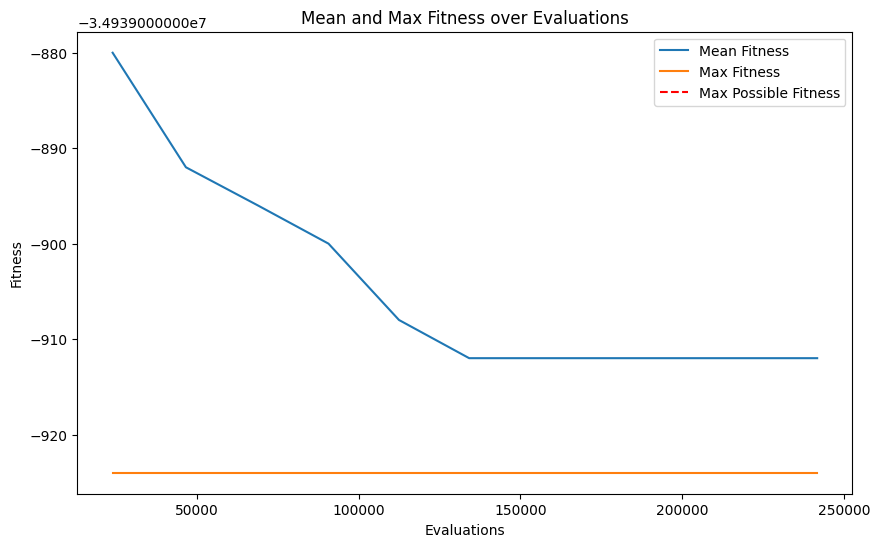

In [193]:
# Custom plot
plt.figure(figsize=(10, 6))
plt.plot(total_evaluations, mean_fitnesses, label='Mean Fitness')
plt.plot(total_evaluations, min_max_fitnesses, label='Max Fitness')
plt.axhline(y=problem.max_fitness, color='r', linestyle='--', label='Max Possible Fitness')
plt.xlabel('Evaluations')
plt.ylabel('Fitness')
plt.title('Mean and Max Fitness over Evaluations')
plt.legend()

# Save plot to W&B
# wandb.log({"fitness_plot": wandb.Image(plt)})

In [194]:
population

tensor([[-1.,  1., -1.,  ..., -1.,  1.,  1.],
        [-1., -1., -1.,  ..., -1.,  1., -1.],
        [-1., -1.,  1.,  ..., -1., -1.,  1.],
        ...,
        [ 1.,  1.,  1.,  ...,  1.,  1., -1.],
        [-1., -1.,  1.,  ..., -1.,  1.,  1.],
        [-1., -1.,  1.,  ...,  1., -1., -1.]])

In [195]:
fitnesses, len(fitnesses)

(tensor([-34939920., -34939904., -34939920., -34939920., -34939920., -34939920.,
         -34939920., -34939920., -34939920., -34939920., -34939920., -34939920.,
         -34939920., -34939920., -34939920., -34939920., -34939916., -34939920.,
         -34939912., -34939920., -34939920., -34939920., -34939920., -34939916.,
         -34939920., -34939920., -34939920., -34939920., -34939916., -34939920.,
         -34939920., -34939896., -34939920., -34939920., -34939924., -34939912.,
         -34939920., -34939920., -34939912., -34939904., -34939896., -34939912.,
         -34939884., -34939920., -34939920., -34939920., -34939920., -34939912.,
         -34939916., -34939920., -34939916., -34939920., -34939920., -34939920.,
         -34939920., -34939920., -34939920., -34939920., -34939924., -34939916.,
         -34939920., -34939920., -34939920., -34939920., -34939904., -34939920.,
         -34939920., -34939916., -34939920., -34939920., -34939920., -34939920.,
         -34939920., -349399

In [196]:
def find_extreme_indices(fitnesses, mode='high'):
    """
    Returns the indices of the highest or lowest values in the list based on the mode.

    Args:
        fitnesses (list or torch.Tensor): A list or tensor of fitness values.
        mode (str): A string that can be either 'high' or 'low'. Defaults to 'high'.

    Returns:
        list: A list of indices corresponding to the extreme values.
    """
    if mode not in ['high', 'low']:
        raise ValueError("Mode should be either 'high' or 'low'")

    if mode == 'high':
        extreme_value = max(fitnesses)
    else:
        extreme_value = min(fitnesses)

    return [i for i, value in enumerate(fitnesses) if value == extreme_value]

In [197]:
def convert_tensor_to_unique_np_arrays(tensor):
    # Convert the tensor to a numpy array
    np_array = tensor.numpy()
    
    # Replace -1 with 0
    np_array[np_array == -1] = 0
    
    # Use a set to track unique arrays based on element ordering
    unique_arrays = set()
    
    # Create a list to store unique numpy arrays
    unique_np_arrays = []
    
    for arr in np_array:
        # Convert the array to a tuple (hashable type) for uniqueness check
        arr_tuple = tuple(arr)
        
        if arr_tuple not in unique_arrays:
            unique_arrays.add(arr_tuple)
            unique_np_arrays.append(arr)
    
    # Convert the list of unique arrays back to a numpy array
    unique_np_array = np.array(unique_np_arrays)
    
    return unique_np_array

In [198]:
def get_solutions(population, fitnesses, mode='low'):
    return convert_tensor_to_unique_np_arrays(population[find_extreme_indices(fitnesses, mode)])

In [199]:
solutions = get_solutions(population, fitnesses, mode='low')
print(len(solutions))
print(len(solutions)/1000*100,'%')

34
3.4000000000000004 %


In [200]:
solutions, solutions[0]

(array([[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 1., ..., 1., 1., 0.],
        [1., 0., 0., ..., 1., 0., 0.],
        ...,
        [1., 0., 1., ..., 1., 0., 1.],
        [0., 0., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 0.]], dtype=float32),
 array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0.,
        1., 1., 0., 1., 0., 0., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0.,
        0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
        1., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
        1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 1.,
        0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32))

In [201]:
def check_equal_count(binary_output, array):
    """
    Check if the count of 0 and 1 in the binary output is equal.
    
    Args:
    binary_output (list): A list of binary values (0s and 1s).
    
    Returns:
    bool: True if the counts are equal, False otherwise.
    """
    partition_1 = [array[i] for i in range(len(array)) if binary_output[i] == 1]
    partition_2 = [array[i] for i in range(len(array)) if binary_output[i] == 0]
    print(len(partition_1), len(partition_2))
    print(sum(partition_1), sum(partition_2))
    print('---')
    return (len(partition_1) == len(partition_2)) & (sum(partition_1) == sum(partition_2))

In [202]:
for solution in solutions:
    if check_equal_count(list(solution), final_durations):
        print(solution)
        break

46 54
5911 5911
---
55 45
5911 5911
---
51 49
5911 5911
---
41 59
5911 5911
---
54 46
5911 5911
---
51 49
5911 5911
---
51 49
5911 5911
---
46 54
5911 5911
---
46 54
5911 5911
---
49 51
5911 5911
---
52 48
5911 5911
---
49 51
5911 5911
---
49 51
5911 5911
---
48 52
5911 5911
---
45 55
5911 5911
---
48 52
5911 5911
---
51 49
5911 5911
---
52 48
5911 5911
---
50 50
5911 5911
---
[0. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1.
 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1.
 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.
 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0.
 0. 1. 0. 0.]


In [203]:
final_durations, solution

(array([132,  13,  72,  27,  43,  25, 192,   6, 167, 188,   1, 113, 197,
        209, 192,  53, 247, 190, 246,   7, 199,  83, 197, 240,  13,   3,
         12, 222, 226, 151, 126, 227,  35,  52,  72, 161, 238,  68,  67,
        204,  86,  58, 152,  85,  47, 173, 154,  40, 103, 160, 120, 122,
         71, 152,  47, 113, 123,  34, 220, 142, 171,  30, 234,  30,  17,
        154, 154, 189,  92, 131,  93, 139, 231,  89, 142,  41,  91, 243,
         77, 124,  15,  14, 144,  70,  50, 212, 163,  99, 161,  32, 147,
        179,   7, 171, 216, 200, 182,   7, 119,  44]),
 array([0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0.,
        0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
        1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0.,
        0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1.,
        1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0.

In [204]:
print(f"Length of final_durations: {len(final_durations)}")
print(f"Length of solution: {len(solution)}")

Length of final_durations: 100
Length of solution: 100


In [205]:
partition_1 = [final_durations[i] for i in range(len(final_durations)) if solution[i] == 1]
partition_2 = [final_durations[i] for i in range(len(final_durations)) if solution[i] == 0]

In [ ]:
partition_1, partition_2, len(partition_1), len(partition_2), sum(partition_1), sum(partition_2)

([13,
  72,
  27,
  167,
  188,
  1,
  53,
  246,
  199,
  197,
  240,
  13,
  3,
  151,
  126,
  67,
  204,
  58,
  152,
  85,
  173,
  40,
  103,
  160,
  120,
  122,
  71,
  152,
  123,
  142,
  171,
  154,
  131,
  231,
  142,
  41,
  91,
  243,
  14,
  144,
  50,
  212,
  163,
  99,
  161,
  32,
  179,
  7,
  171,
  7],
 [132,
  43,
  25,
  192,
  6,
  113,
  197,
  209,
  192,
  247,
  190,
  7,
  83,
  12,
  222,
  226,
  227,
  35,
  52,
  72,
  161,
  238,
  68,
  86,
  47,
  154,
  47,
  113,
  34,
  220,
  30,
  234,
  30,
  17,
  154,
  189,
  92,
  93,
  139,
  89,
  77,
  124,
  15,
  70,
  147,
  216,
  200,
  182,
  119,
  44],
 50,
 50,
 5911,
 5911)